# Notebook 09 — Paper Figures

This notebook reads every JSON / PNG artifact produced by the eye (`eye/01..08`) and lane (`lane/01..08`) pipelines and emits the figures and tables for the 6–8 page IEEE technical paper.

Sections:
1. Comparison tables (classical vs CNN-scratch vs transfer learning vs lightweight, per pipeline)
2. Training-curve overlays
3. Robustness bars
4. Pareto frontier figures
5. Deployment latency + size charts
6. A single-page "summary" figure suitable for the abstract.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
ART = ROOT / "artifacts"
PAPER = ROOT / "paper"; PAPER.mkdir(exist_ok=True)
FIG = PAPER / "figures"; FIG.mkdir(exist_ok=True)
print("artifacts dir:", ART)
print("paper figures dir:", FIG)

artifacts dir: D:\Spring forth year\Computer Vision\project\artifacts
paper figures dir: D:\Spring forth year\Computer Vision\project\paper\figures


## 1. Comparison tables

In [2]:
def jload(p): return json.load(open(p))

eye = {
    "classical": jload(ART / "eye02_classical_results.json"),
    "cnn_scratch": jload(ART / "eye03_cnn_results.json"),
    "tl": jload(ART / "eye04_transfer_learning_results.json"),
    "exp": jload(ART / "eye05_experiments.json"),
    "selection": jload(ART / "eye06_selection.json"),
    "deploy": jload(ART / "eye08_deployment.json"),
}
lane = {
    "classical": jload(ART / "lane02_classical_results.json"),
    "cnn_scratch": jload(ART / "lane03_cnn_results.json"),
    "tl": jload(ART / "lane04_transfer_learning_results.json"),
    "exp": jload(ART / "lane05_experiments.json"),
    "selection": jload(ART / "lane06_selection.json"),
    "deploy": jload(ART / "lane08_deployment.json"),
    "finetune": jload(ART / "lane07_finetune_results.json"),
}

def _g(d, *keys, default=None):
    # First-present key getter (handles schema drift between eye/lane JSONs).
    for k in keys:
        if k in d and d[k] is not None: return d[k]
    return default

def make_table(pipe_dict, pipe_name):
    rows = []
    cls = pipe_dict["classical"]
    rows.append({"family": "classical", "name": _g(cls, "name", "model", default="classical"),
                 "accuracy": cls["accuracy"],
                 "f1": _g(cls, "f1", "f1_macro"),
                 "n_params": cls["n_params"]})
    cnn = pipe_dict["cnn_scratch"]
    rows.append({"family": "cnn_scratch", "name": _g(cnn, "name", "model", default="cnn_scratch"),
                 "accuracy": cnn["accuracy"],
                 "f1": _g(cnn, "f1", "f1_macro"),
                 "n_params": cnn["n_params"]})
    for c in pipe_dict["tl"]["candidates"]:
        rows.append({"family": "transfer_learning", "name": c["name"],
                     "accuracy": c["accuracy"], "f1": c["f1"], "n_params": c["n_params"]})
    for tag in ["tiny", "baseline", "wide"]:
        e = pipe_dict["exp"]["expD_lightweight"][tag]
        rows.append({"family": "lightweight", "name": f"lw_{tag}",
                     "accuracy": e["accuracy"], "f1": e["f1"], "n_params": e["n_params"]})
    df = pd.DataFrame(rows).round(4)
    return df

tbl_eye  = make_table(eye, "eye")
tbl_lane = make_table(lane, "lane")
print("EYE pipeline:");  display(tbl_eye)
print("LANE pipeline:"); display(tbl_lane)
tbl_eye.to_csv(PAPER / "table1_eye.csv",  index=False)
tbl_lane.to_csv(PAPER / "table1_lane.csv", index=False)
print("Saved paper/table1_eye.csv and table1_lane.csv")

EYE pipeline:


,family,name,accuracy,f1,n_params
0,classical,classical_hog_svm,0.8736,0.8763,4357
1,cnn_scratch,cnn_baseline_from_scratch,0.8956,0.8984,25778
2,transfer_learning,mobilenetv3_small_frozen,0.8516,0.8586,940274
3,transfer_learning,mobilenetv3_small_finetune,0.8434,0.8472,940274
4,transfer_learning,mobilenetv2_frozen,0.8736,0.8715,2260546
5,transfer_learning,mobilenetv2_finetune,0.8846,0.8877,2260546
6,lightweight,lw_tiny,0.8736,0.8729,4328
7,lightweight,lw_baseline,0.8956,0.8984,25778
8,lightweight,lw_wide,0.9066,0.9096,97538


LANE pipeline:


,family,name,accuracy,f1,n_params
0,classical,classical_hough_svm,0.5050,0.5750,0
1,cnn_scratch,cnn_from_scratch,0.7023,0.6592,86276
2,transfer_learning,mobilenetv2_frozen,0.7241,0.7379,711348
3,transfer_learning,mobilenetv2_finetune,0.7759,0.7785,711348
4,transfer_learning,mobilenetv3_small_frozen,0.6070,0.6428,584892
5,transfer_learning,mobilenetv3_small_finetune,0.7107,0.6819,584892
6,lightweight,lw_tiny,0.6405,0.5445,7300
7,lightweight,lw_baseline,0.7441,0.7752,86276
8,lightweight,lw_wide,0.7458,0.7212,195300


Saved paper/table1_eye.csv and table1_lane.csv


## 2. Training-curve overlays (eye + lane)

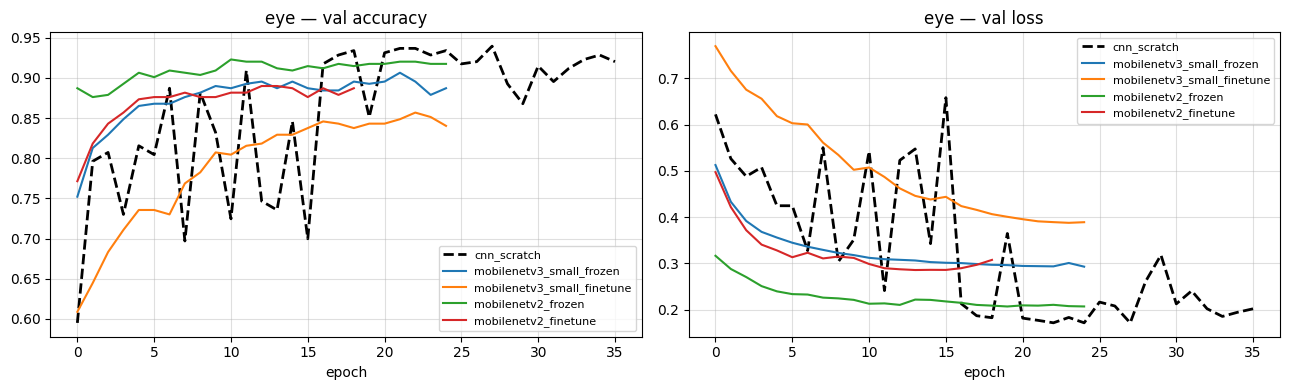

Saved paper\figures\fig_eye_curves.png


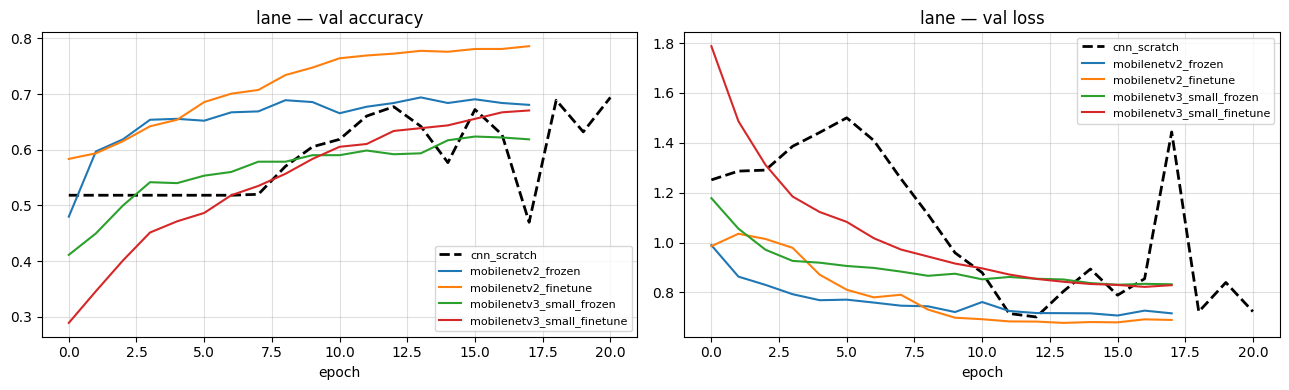

Saved paper\figures\fig_lane_curves.png


In [3]:
for pipe_name, P in [("eye", eye), ("lane", lane)]:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    h0 = _g(P["cnn_scratch"], "history", "train_history", default={})
    if h0:
        va = _g(h0, "val_accuracy", "val_acc", default=[])
        vl = _g(h0, "val_loss", default=[])
        if va: axes[0].plot(va, "k--", lw=2, label="cnn_scratch")
        if vl: axes[1].plot(vl, "k--", lw=2, label="cnn_scratch")
    for c in P["tl"]["candidates"]:
        h = _g(c, "history", "train_history", default={})
        if not h: continue
        va = _g(h, "val_accuracy", "val_acc", default=[])
        vl = _g(h, "val_loss", default=[])
        if va: axes[0].plot(va, label=c["name"])
        if vl: axes[1].plot(vl, label=c["name"])
    axes[0].set_title(f"{pipe_name} — val accuracy"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.4); axes[0].legend(fontsize=8)
    axes[1].set_title(f"{pipe_name} — val loss");     axes[1].set_xlabel("epoch"); axes[1].grid(alpha=0.4); axes[1].legend(fontsize=8)
    plt.tight_layout()
    out = FIG / f"fig_{pipe_name}_curves.png"
    plt.savefig(out, dpi=120, bbox_inches="tight"); plt.show()
    print(f"Saved {out.relative_to(ROOT)}")

## 3. Robustness bars side-by-side

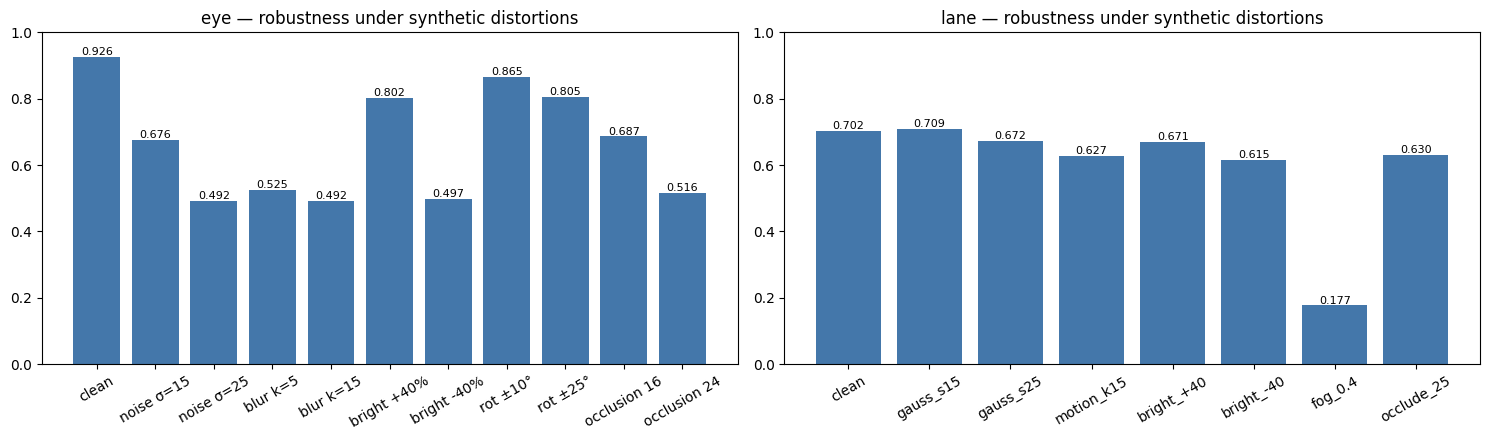

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, (pipe_name, P) in zip(axes, [("eye", eye), ("lane", lane)]):
    r = P["exp"]["expC_robustness"]
    xs = list(r); ys = [r[k]["accuracy"] for k in xs]
    ax.bar(xs, ys, color="#4477aa")
    for i, v in enumerate(ys): ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=8)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{pipe_name} — robustness under synthetic distortions")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG / "fig_robustness.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Pareto frontier — eye + lane side-by-side

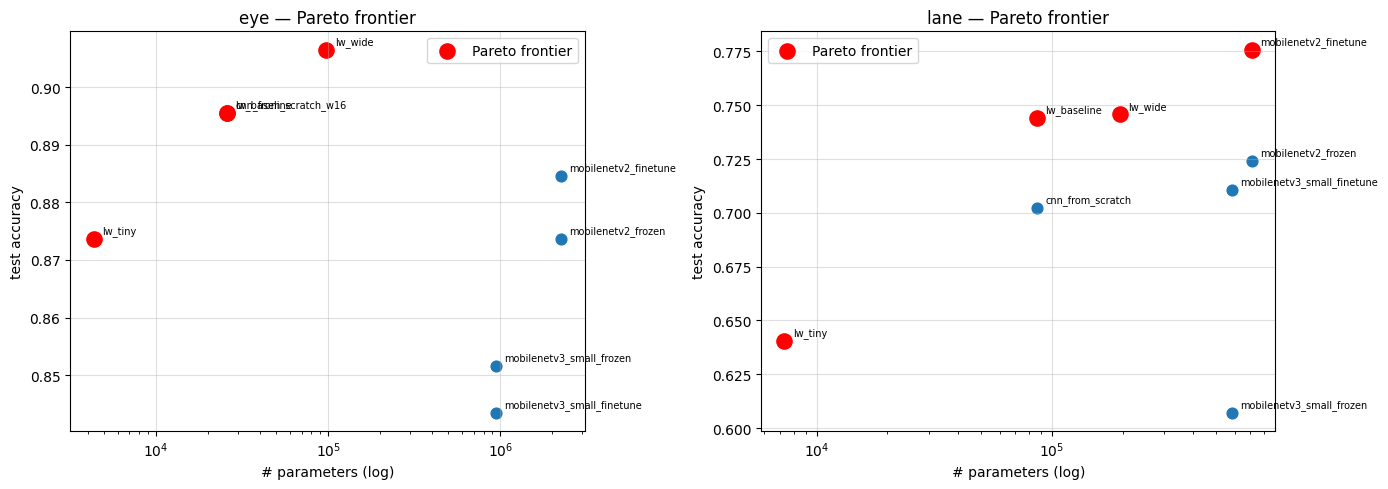

In [5]:
def pareto_indices(points):
    n = len(points); keep = np.ones(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if (points[j, 0] >= points[i, 0] and points[j, 1] <= points[i, 1]
                and (points[j, 0] > points[i, 0] or points[j, 1] < points[i, 1])):
                keep[i] = False; break
    return np.where(keep)[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (pipe_name, P) in zip(axes, [("eye", eye), ("lane", lane)]):
    cands = P["selection"]["candidates"]
    pts = np.array([[c["accuracy"], c["n_params"]] for c in cands])
    pf  = pareto_indices(pts)
    ax.scatter(pts[:, 1], pts[:, 0], s=60)
    ax.scatter(pts[pf, 1], pts[pf, 0], color="red", s=120, label="Pareto frontier")
    for i, c in enumerate(cands):
        ax.annotate(c["name"], (pts[i, 1], pts[i, 0]),
                    fontsize=7, xytext=(6, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("# parameters (log)"); ax.set_ylabel("test accuracy")
    ax.set_title(f"{pipe_name} — Pareto frontier"); ax.grid(alpha=0.4); ax.legend()
plt.tight_layout()
plt.savefig(FIG / "fig_pareto.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Deployment latency + size bars

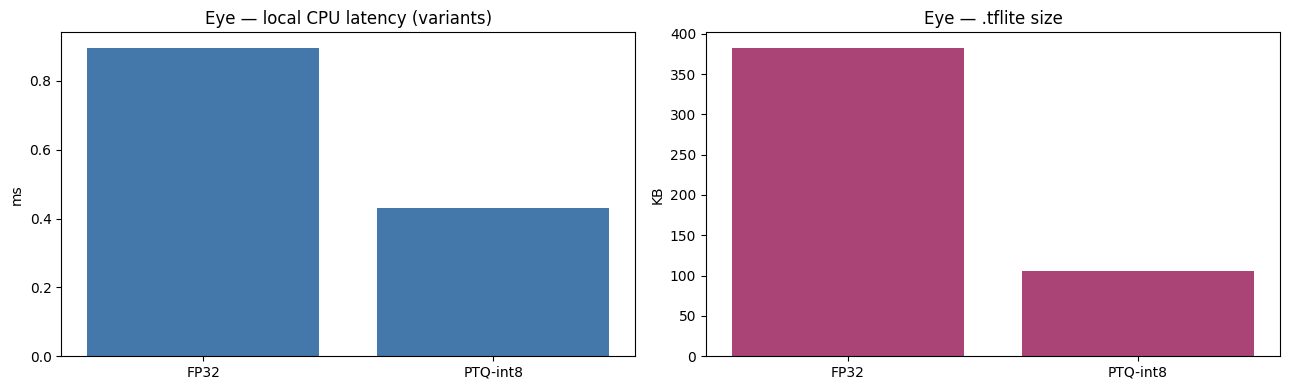

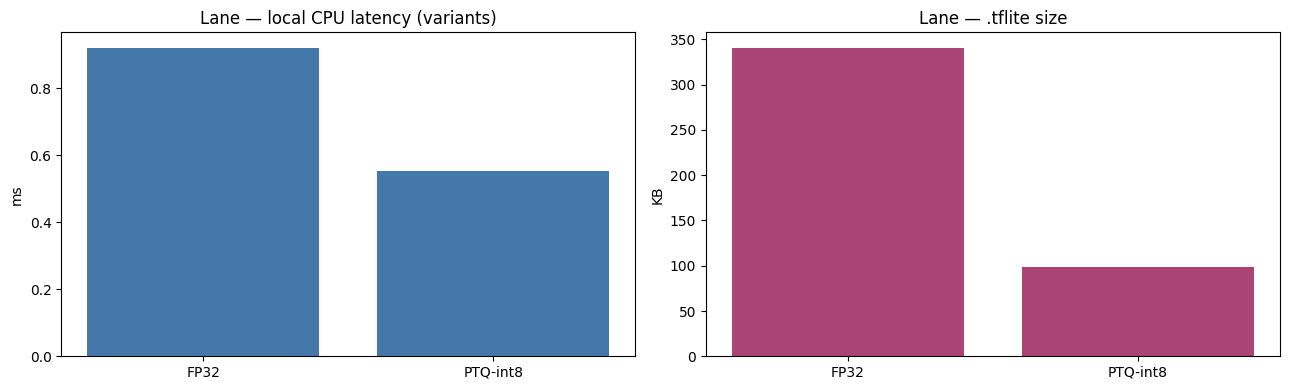

In [6]:
# Eye deployment
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ed = eye["deploy"]
tags = list(ed)
axes[0].bar(tags, [ed[t]["latency_ms_local_cpu"] for t in tags], color="#4477aa")
axes[0].set_ylabel("ms"); axes[0].set_title("Eye — local CPU latency (variants)")
axes[1].bar(tags, [ed[t]["size_kb"] for t in tags], color="#aa4477")
axes[1].set_ylabel("KB"); axes[1].set_title("Eye — .tflite size")
plt.tight_layout()
plt.savefig(FIG / "fig_eye_deploy.png", dpi=120, bbox_inches="tight")
plt.show()

# Lane deployment
ld = lane["deploy"]["variants_local"]
tags = list(ld)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(tags, [ld[t]["latency_ms_local_cpu_4thr"] for t in tags], color="#4477aa")
axes[0].set_ylabel("ms"); axes[0].set_title("Lane — local CPU latency (variants)")
axes[1].bar(tags, [ld[t]["size_kb"] for t in tags], color="#aa4477")
axes[1].set_ylabel("KB"); axes[1].set_title("Lane — .tflite size")
plt.tight_layout()
plt.savefig(FIG / "fig_lane_deploy.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Summary 2x2 figure (suitable for the paper's first page)

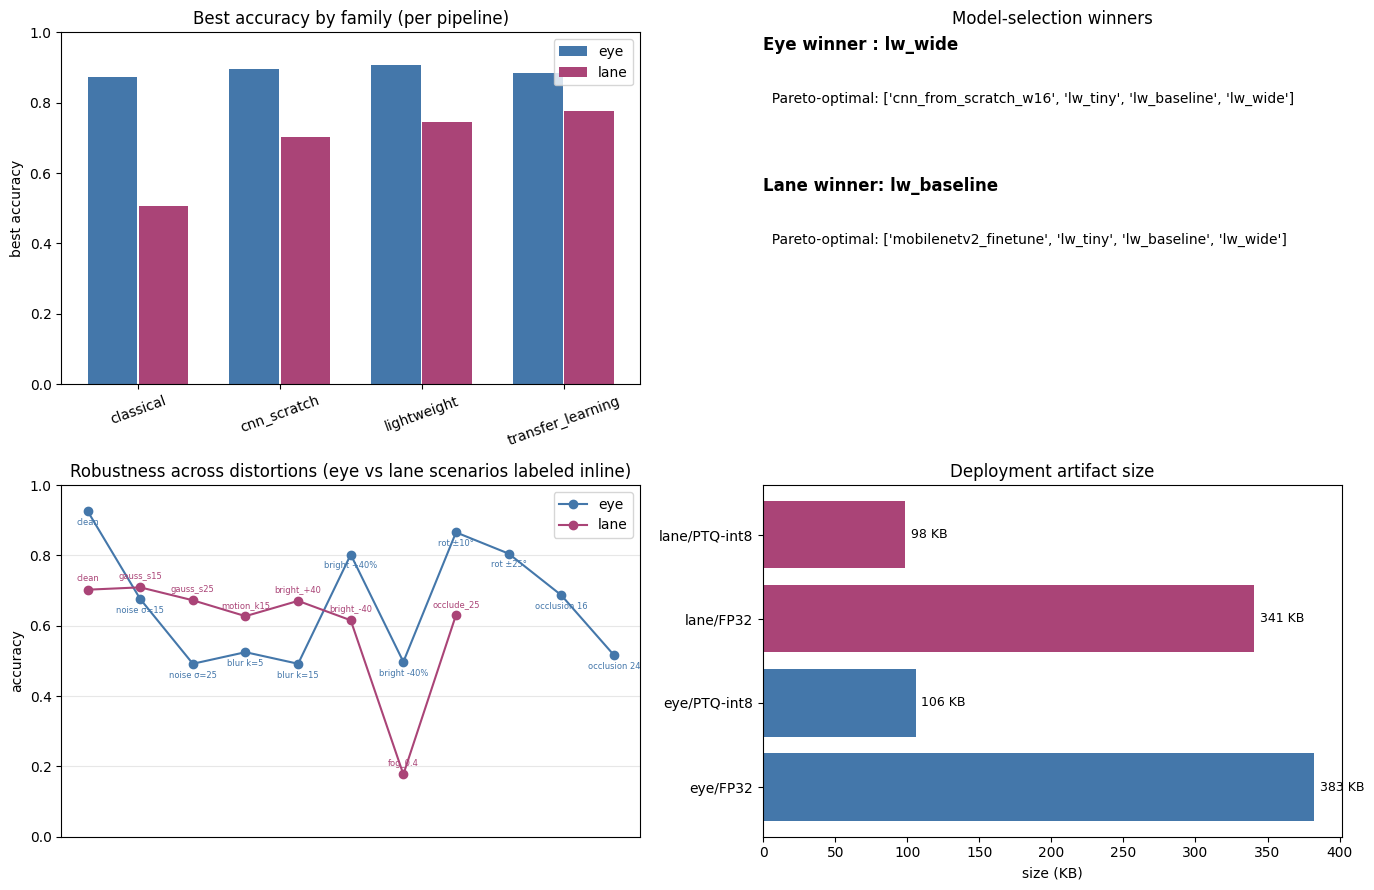

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
# panel 1: accuracy by family per pipeline
def family_acc(df):
    return df.groupby("family")["accuracy"].max()

eye_acc  = family_acc(tbl_eye)
lane_acc = family_acc(tbl_lane)
families = sorted(set(eye_acc.index) | set(lane_acc.index))
x = np.arange(len(families))
axes[0, 0].bar(x - 0.18, [eye_acc.get(f, 0)  for f in families], 0.35, label="eye",  color="#4477aa")
axes[0, 0].bar(x + 0.18, [lane_acc.get(f, 0) for f in families], 0.35, label="lane", color="#aa4477")
axes[0, 0].set_xticks(x); axes[0, 0].set_xticklabels(families, rotation=20)
axes[0, 0].set_ylim(0, 1.0); axes[0, 0].set_ylabel("best accuracy")
axes[0, 0].set_title("Best accuracy by family (per pipeline)")
axes[0, 0].legend()

# panel 2: winner summary
sel_e = eye["selection"]; sel_l = lane["selection"]
axes[0, 1].axis("off")
axes[0, 1].text(0.0, 0.95, f"Eye winner : {sel_e['winner']}", fontsize=12, fontweight="bold")
axes[0, 1].text(0.0, 0.80, f"  Pareto-optimal: {sel_e['pareto']}", fontsize=10)
axes[0, 1].text(0.0, 0.55, f"Lane winner: {sel_l['winner']}", fontsize=12, fontweight="bold")
axes[0, 1].text(0.0, 0.40, f"  Pareto-optimal: {sel_l['pareto']}", fontsize=10)
axes[0, 1].set_title("Model-selection winners")

# panel 3: robustness comparison
ax = axes[1, 0]
# Each pipeline has its own robustness scenarios; plot separately on a shared axis using positional index.
for label, P, color in [("eye", eye, "#4477aa"), ("lane", lane, "#aa4477")]:
    rob = P["exp"]["expC_robustness"]
    ks = list(rob); ys = [rob[k]["accuracy"] for k in ks]
    ax.plot(range(len(ks)), ys, marker="o", color=color, label=label)
    for i, k in enumerate(ks):
        ax.annotate(k, (i, ys[i]), fontsize=6, xytext=(0, -10 if label == "eye" else 6),
                    textcoords="offset points", ha="center", color=color)
ax.set_xticks([]); ax.set_ylim(0, 1.0); ax.set_ylabel("accuracy")
ax.set_title("Robustness across distortions (eye vs lane scenarios labeled inline)")
ax.legend(); ax.grid(alpha=0.3)

# panel 4: deployment compactness
ax = axes[1, 1]
labels = []
sizes = []
for tag, v in eye["deploy"].items():
    labels.append(f"eye/{tag}"); sizes.append(v["size_kb"])
for tag, v in lane["deploy"]["variants_local"].items():
    labels.append(f"lane/{tag}"); sizes.append(v["size_kb"])
ax.barh(labels, sizes, color=["#4477aa" if l.startswith("eye") else "#aa4477" for l in labels])
for i, v in enumerate(sizes): ax.text(v + max(sizes)*0.01, i, f"{v:.0f} KB", va="center", fontsize=9)
ax.set_xlabel("size (KB)"); ax.set_title("Deployment artifact size")

plt.tight_layout()
plt.savefig(FIG / "fig_summary.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Write a short markdown summary into `paper/`

In [8]:
md = []
md.append(f"# Project numerical summary\n")
md.append(f"## Eye pipeline (Samsung S24 Ultra target)\n")
md.append(f"- classical HOG+SVM     acc {eye['classical']['accuracy']:.4f}  f1 {_g(eye['classical'], 'f1', 'f1_macro', default=0):.4f}")
md.append(f"- custom CNN (scratch)  acc {eye['cnn_scratch']['accuracy']:.4f}  f1 {_g(eye['cnn_scratch'], 'f1', 'f1_macro', default=0):.4f}  ({eye['cnn_scratch']['n_params']:,} params)")
for c in eye["tl"]["candidates"]:
    md.append(f"- {c['name']:30s}  acc {c['accuracy']:.4f}  f1 {c['f1']:.4f}  ({c['n_params']:,} params)")
md.append(f"- WINNER: **{eye['selection']['winner']}**\n")
md.append(f"## Lane pipeline (Raspberry Pi 4 target)\n")
md.append(f"- classical Hough+SVM   acc {lane['classical']['accuracy']:.4f}  f1 {lane['classical']['f1_macro']:.4f}")
md.append(f"- custom CNN (scratch)  acc {lane['cnn_scratch']['accuracy']:.4f}  f1 {lane['cnn_scratch']['f1']:.4f}  ({lane['cnn_scratch']['n_params']:,} params)")
for c in lane["tl"]["candidates"]:
    md.append(f"- {c['name']:30s}  acc {c['accuracy']:.4f}  f1 {c['f1']:.4f}  ({c['n_params']:,} params)")
md.append(f"- WINNER: **{lane['selection']['winner']}**\n")
md.append(f"- Pi fine-tune: acc {lane['finetune']['acc_before']:.4f} -> {lane['finetune']['acc_after']:.4f}\n")
md.append(f"## Deployment\n- Eye PTQ-int8: {eye['deploy']['PTQ-int8']['size_kb']:.0f} KB, {eye['deploy']['PTQ-int8']['latency_ms_local_cpu']:.2f} ms local CPU")
md.append(f"- Lane PTQ-int8: {lane['deploy']['variants_local']['PTQ-int8']['size_kb']:.0f} KB, {lane['deploy']['variants_local']['PTQ-int8']['latency_ms_local_cpu_4thr']:.2f} ms local CPU 4thr")

txt = "\n".join(md)
print(txt)
(PAPER / "summary.md").write_text(txt)
print("\nSaved paper/summary.md")

# Project numerical summary

## Eye pipeline (Samsung S24 Ultra target)

- classical HOG+SVM     acc 0.8736  f1 0.8763
- custom CNN (scratch)  acc 0.8956  f1 0.8984  (25,778 params)
- mobilenetv3_small_frozen        acc 0.8516  f1 0.8586  (940,274 params)
- mobilenetv3_small_finetune      acc 0.8434  f1 0.8472  (940,274 params)
- mobilenetv2_frozen              acc 0.8736  f1 0.8715  (2,260,546 params)
- mobilenetv2_finetune            acc 0.8846  f1 0.8877  (2,260,546 params)
- WINNER: **lw_wide**

## Lane pipeline (Raspberry Pi 4 target)

- classical Hough+SVM   acc 0.5050  f1 0.5750
- custom CNN (scratch)  acc 0.7023  f1 0.6592  (86,276 params)
- mobilenetv2_frozen              acc 0.7241  f1 0.7379  (711,348 params)
- mobilenetv2_finetune            acc 0.7759  f1 0.7785  (711,348 params)
- mobilenetv3_small_frozen        acc 0.6070  f1 0.6428  (584,892 params)
- mobilenetv3_small_finetune      acc 0.7107  f1 0.6819  (584,892 params)
- WINNER: **lw_baseline**

- Pi fine-tune: acc 0

## Summary

All figures land in `paper/figures/` and tables in `paper/`. The paper LaTeX template can `\includegraphics{figures/fig_*.png}`.